In [11]:
import tensorflow
import keras
from tensorflow.keras import Sequential
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from PIL import Image
import kagglehub
import os

In [12]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.


In [13]:
train_path = "/kaggle/input/gtsrb-german-traffic-sign/Train"
classes = 43
data = []
class_labels = []
for i in range(classes):
  img_path = train_path + "/" + str(i)
  for img in os.listdir(img_path):
    im = Image.open(img_path + "/" + img)
    im = im.resize((60,60))
    im = np.array(im)
    data.append(im)
    class_labels.append(i)

In [14]:
data = np.array(data)
class_labels = np.array(class_labels)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, class_labels, test_size=0.2, random_state=42)

In [15]:
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)
x_train = X_train/255
X_test = X_test/255

In [16]:
neural_model = Sequential([
    Conv2D(filters=32, kernel_size = (5,5), activation = "relu", input_shape = (60,60,3)),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(filters=64, kernel_size = (5,5), activation = "relu"),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(600, activation = "relu"),
    Dropout(0.2),
    Dense(300, activation = "relu"),
    Dropout(0.2),
    Dense(100, activation = "relu"),
    Dense(43, activation = "softmax")
])
neural_model.compile(optimizer = "Adam", loss = "categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
history = neural_model.fit(x_train, y_train, batch_size = 32, epochs = 20, validation_data = (X_test, y_test))

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7563 - loss: 0.8531 - val_accuracy: 0.9668 - val_loss: 0.1262
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9694 - loss: 0.1090 - val_accuracy: 0.9852 - val_loss: 0.0585
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9810 - loss: 0.0672 - val_accuracy: 0.9890 - val_loss: 0.0450
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9874 - loss: 0.0432 - val_accuracy: 0.9867 - val_loss: 0.0655
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9898 - loss: 0.0368 - val_accuracy: 0.9889 - val_loss: 0.0612
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9896 - loss: 0.0396 - val_accuracy: 0.9857 - val_loss: 0.0550
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9915 - loss: 0.0332 - val_accuracy: 0.9880 - val_loss: 0.0521
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9921 - loss: 0.0330 - val_accuracy: 

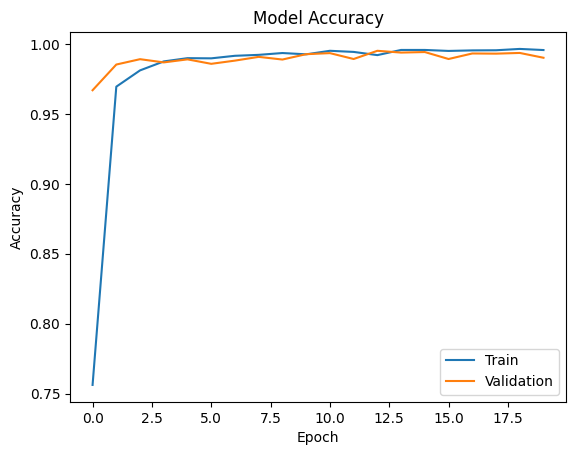

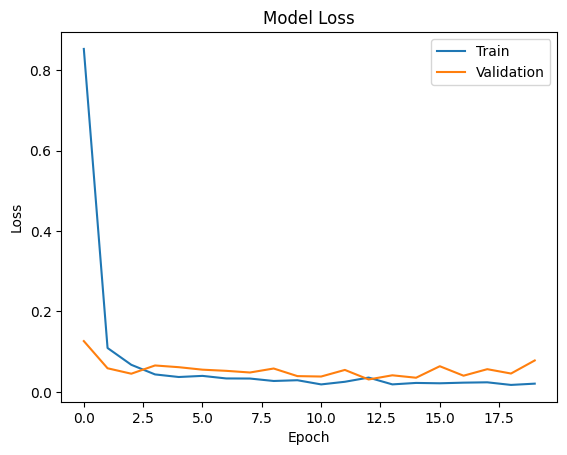

In [18]:
#graphs
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
neural_model.save("germantraffic.h5")
from google.colab import files
files.download("germantraffic.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>